In [1]:
import pandas as pd
from torch.nn import MSELoss, HuberLoss

pd.set_option('display.max_columns', None)

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

import torch
from torch import nn
import torch.optim
from torchinfo import summary




In [2]:
import os
import sys

project_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..')) 

sys.path.append(os.path.join(project_root, 'Scripts'))

from model_utils.data import *
from data_utils.colors_config import *
from data_utils.processing import *
from model_utils.trainer import *

/opt/python/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
current_dir = os.path.dirname(os.path.abspath('__file__'))
root_dir = os.path.abspath(os.path.join(current_dir, '../../'))

if root_dir not in sys.path:
    sys.path.append(root_dir)

import config

In [4]:
set_seed(77)

In [5]:
data = pd.read_parquet(config.FPL_DATA_PATH)

In [6]:
data.isna().sum().sum()

np.int64(0)

In [7]:
data = sort_data(data)
data.columns

Index(['transfers_in', 'position', 'element', 'gw', 'code', 'season',
       'transfers_balance', 'was_home', 'name', 'selected', 'transfers_out',
       'value', 'transfers_trend', 'kickoff_time', 'total_points',
       'bonus_ema_8', 'bps_ema_8', 'value_ema_8', 'threat_ema_8',
       'transfers_out_ema_8', 'transfers_balance_ema_8', 'transfers_in_ema_8',
       'transfers_trend_ema_8', 'yellow_cards_ema_8',
       'xg_conceded_per_90_ema_8', 'xg_involvements_per_90_ema_8',
       'xg_per_90_ema_8', 'xa_per_90_ema_8', 'own_goals_ema_8',
       'assists_ema_8', 'saves_ema_8', 'penalties_saved_ema_8', 'xp_ema_8',
       'penalties_missed_ema_8', 'team_h_score_ema_8', 'xa_ema_8',
       'team_a_score_ema_8', 'red_cards_ema_8', 'total_points_ema_8',
       'transfers_out_lagged_1', 'transfers_balance_lagged_1',
       'transfers_in_lagged_1', 'transfers_trend_lagged_1',
       'xg_conceded_per_90_lagged_1', 'xg_involvements_per_90_lagged_1',
       'xg_per_90_lagged_1', 'xa_per_90_lagged_

In [8]:
[c for c in data.columns if "min" in c]

[]

In [9]:
data.shape

(100409, 54)

In [10]:
cols_map = colors_config.FEATURES_GROUP

In [11]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [12]:
cols_map["static_cols"]

['position', 'was_home', 'starts']

In [13]:
cols_map["pre_game_cols"][:10]

['name',
 'position',
 'element',
 'was_home',
 'was_home',
 'gw',
 'code',
 'season',
 'kickoff_time',
 'value']

In [14]:
num_cols = [c for c in data.columns if "ema" in c or "lagg" in c] + [c for c in cols_map["pre_game_cols"] if c in data.columns and c not in ["name", "position", "element", "opponent_team", "gw", "code", "season", 'kickoff_time']]
len(num_cols)

47

In [15]:
cols_map["static_cols"]

['position', 'was_home', 'starts']

In [16]:
BATCH_SIZE = 256
fpl_data_pipe = FPLDataPipe(num_cols=[c for c in num_cols if c in data.columns],
                            cat_cols = [c for c in cols_map["static_cols"] if c in data.columns and c != "web_name" and c != "player_id" and c != "gw"],
                            batch_size=BATCH_SIZE)

In [17]:
data_splits = train_test_split(data)
fpl_data_pipe.prepare_data(**data_splits)

In [18]:
data_splits.get("X_train").shape

(56230, 53)

In [19]:
train_dataloader, valid_dataloader, test_dataloader = fpl_data_pipe.get_dataloaders()

In [20]:
x, y = next(iter(train_dataloader))
x.shape, y.shape

(torch.Size([256, 51]), torch.Size([256, 1]))

In [21]:
class ConvNN(nn.Module):
    def __init__(self,
                 input_size: int,
                 conv_channels1: int,
                 conv_channels2: int,
                 hidden_size1: int,
                 hidden_size2: int,
                 output_size: int):

        super().__init__()

        self.conv_block = nn.Sequential(
            nn.Conv1d(1, conv_channels1, 3, padding=1),
            nn.LeakyReLU(0.01),
            nn.BatchNorm1d(conv_channels1),

            nn.Conv1d(conv_channels1, conv_channels2, 3, padding=1),
            nn.LeakyReLU(0.01),
            nn.BatchNorm1d(conv_channels2),
        )

        # 🔥 zamiast Flatten
        self.pool = nn.AdaptiveAvgPool1d(1)

        self.fc_block = nn.Sequential(
            nn.Linear(conv_channels2, hidden_size1),
            nn.LeakyReLU(0.01),
            nn.BatchNorm1d(hidden_size1),
            nn.Dropout(0.2),

            nn.Linear(hidden_size1, hidden_size2),
            nn.LeakyReLU(0.01),
            nn.BatchNorm1d(hidden_size2),
            nn.Dropout(0.1),

            nn.Linear(hidden_size2, output_size)
        )

    def forward(self, x):
        x = x.unsqueeze(1)        # (B,1,F)
        x = self.conv_block(x)    # (B,C,F)
        x = self.pool(x)          # (B,C,1)
        x = x.squeeze(-1)         # (B,C)
        return self.fc_block(x)

In [22]:
class MLP(nn.Module):
    def __init__(self, input_size: int,
                 hidden_size1: int,
                 hidden_size2: int,
                 output_size: int):
        super(MLP, self).__init__()

        block1 = nn.Sequential(
            nn.Linear(input_size, hidden_size1),
            nn.LeakyReLU(.01),
            nn.BatchNorm1d(hidden_size1),
            nn.Dropout(0.2)
        )
        block2 = nn.Sequential(
            nn.Linear(hidden_size1, hidden_size2),
            nn.LeakyReLU(.01),
            nn.BatchNorm1d(hidden_size2),
            nn.Dropout(0.1)
        )
        block3 = nn.Sequential(
            nn.Linear(hidden_size2, output_size)
        )

        self.block_stack = nn.Sequential(
            block1,
            block2,
            block3
        )

    def forward(self, x):
        return self.block_stack(x)

In [23]:
mlp = MLP(
    input_size=x.shape[1],
    hidden_size1=128,
    hidden_size2=64,
    output_size=1
).to(device)

In [24]:
model = ConvNN(
    input_size=x.shape[1],
    conv_channels1=32,
    conv_channels2=64,
    hidden_size1=128,
    hidden_size2=64,
    output_size=1
).to(device)

In [25]:
x.shape

torch.Size([256, 51])

In [26]:
summary(
    model=mlp,
    input_size=(BATCH_SIZE, x.shape[1]),
    col_names=["input_size", "output_size", "num_params", "trainable"],
    col_width=18

)

Layer (type:depth-idx)                   Input Shape        Output Shape       Param #            Trainable
MLP                                      [256, 51]          [256, 1]           --                 True
├─Sequential: 1-1                        [256, 51]          [256, 1]           --                 True
│    └─Sequential: 2-1                   [256, 51]          [256, 128]         --                 True
│    │    └─Linear: 3-1                  [256, 51]          [256, 128]         6,656              True
│    │    └─LeakyReLU: 3-2               [256, 128]         [256, 128]         --                 --
│    │    └─BatchNorm1d: 3-3             [256, 128]         [256, 128]         256                True
│    │    └─Dropout: 3-4                 [256, 128]         [256, 128]         --                 --
│    └─Sequential: 2-2                   [256, 128]         [256, 64]          --                 True
│    │    └─Linear: 3-5                  [256, 128]         [256, 64]   

In [27]:
learning_rate = 0.001
weight_decay = .05
loss_fn = MSELoss(reduction="none")
optimizer = torch.optim.Adam(lr=learning_rate,
                            params=mlp.parameters(),
                            weight_decay=weight_decay)


In [28]:
trainer = Trainer(device=device,
                  random_state=77)

In [29]:
MODEL = [mlp]
MODEL_NAME = [m.__class__.__name__ for m in MODEL]

In [30]:
NUM_EPOCHS = 20
BEST_MODELS = []
for m, name in zip(MODEL, MODEL_NAME):
    print(f"MODEL: {name}")
    results, best_model = trainer.model_eval(train_dataloader=train_dataloader,
                             test_dataloader=valid_dataloader,
                             model=m,
                             num_epochs=NUM_EPOCHS,
                             optimizer=optimizer,
                             loss_fn=loss_fn,
                             patience=NUM_EPOCHS//2)
    BEST_MODELS.append(best_model)

MODEL: MLP


  0%|          | 0/20 [00:00<?, ?it/s]


RuntimeError: grad can be implicitly created only for scalar outputs

In [ ]:
results_frame = pd.DataFrame(results)


In [ ]:
results_frame.head()

,train_loss,test_loss,train_mse,test_mse,train_mae,test_mae,train_r2,test_r2,lr
0,1.433701,1.098524,5.495985,4.692326,1.627770,1.440655,-0.017738,0.121162,0.001
1,1.139504,1.071887,5.016412,5.241038,1.504312,1.539570,0.071069,0.018393,0.001
2,1.105993,1.109589,5.117817,4.093576,1.508237,1.263773,0.052291,0.233304,0.001
3,1.103699,1.056941,4.970748,4.913183,1.466203,1.440673,0.079525,0.079797,0.001
4,1.101954,1.062645,5.003967,5.107312,1.461321,1.524976,0.073373,0.043439,0.001


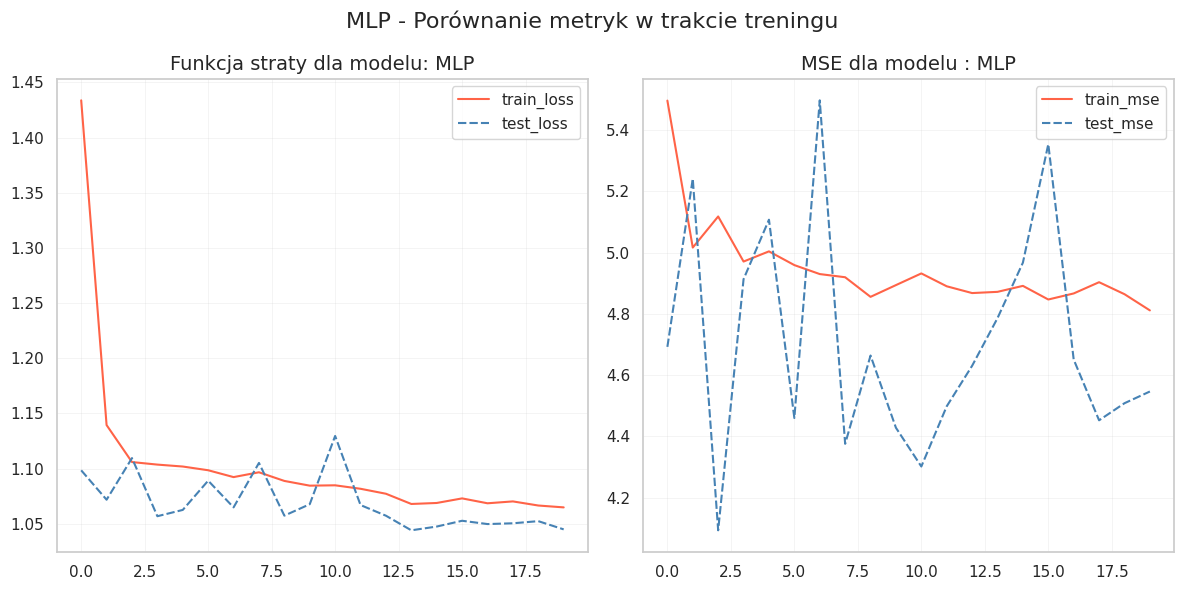

In [ ]:
fig, ax = plt.subplots(nrows=len(MODEL), ncols=2, figsize=(12, 6))

for i, name in enumerate(MODEL_NAME):
    sns.lineplot(data=results_frame[["train_loss", "test_loss"]],
                palette=["tomato", "steelblue"],
                ax=ax[i])
    ax[i].set_title(f"Funkcja straty dla modelu: {name}", fontsize=14)

    sns.lineplot(data=results_frame[["train_mse", "test_mse"]],
                palette=["tomato", "steelblue"],
                ax=ax[i+1])
    ax[i+1].set_title(f"MSE dla modelu : {name}", fontsize=14)

    fig.suptitle(f"{name} - Porównanie metryk w trakcie treningu", fontsize=16)
    plt.tight_layout()
    plt.show()

In [ ]:
test_results = trainer.test_step(test_dataloader=test_dataloader, model=mlp, loss_fn=loss_fn)[0:3]

y_pred = trainer.test_step(test_dataloader=test_dataloader, model=mlp, loss_fn=loss_fn)[4]

In [ ]:
y_test = data_splits["y_test"]

In [ ]:
y_pred.shape, y_test.shape

(torch.Size([16896, 1]), (16896,))

In [ ]:
preds = pd.DataFrame({
    "name" : data.loc[y_test.index, "name"],
    "y_true": y_test.values,
    "y_pred": y_pred.numpy().flatten(),
    "season" : data.loc[y_test.index, "season"],
     "gw": data.loc[y_test.index, "gw"]
})

In [ ]:
preds.y_pred.max(), preds.y_true.max()

(np.float32(48255.12), np.float64(24.0))

In [ ]:
preds.y_pred.min(), preds.y_true.min()

(np.float32(-87069.555), np.float64(-3.0))

In [ ]:
preds.y_pred.var(), preds.y_true.var() 

(np.float32(2.2515546e+07), np.float64(5.482395524356094))

In [ ]:
preds.tail()

,name,y_true,y_pred,season,gw
100404,George Brierley,0.0,-0.056078,2526.0,27.0
100405,George Brierley,0.0,-0.159238,2526.0,28.0
100406,George Brierley,0.0,-0.100013,2526.0,29.0
100407,George Brierley,0.0,-0.122785,2526.0,30.0
100408,George Brierley,0.0,-0.064454,2526.0,32.0


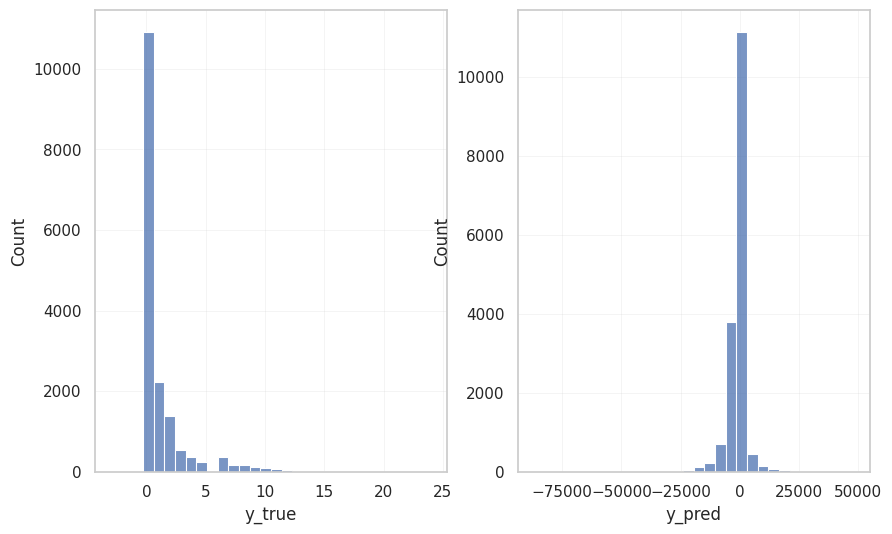

In [ ]:
fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(10, 6))
for i, col in enumerate(["y_true", "y_pred"]):
    sns.histplot(data=preds[col], ax=ax[i], bins=30)

In [ ]:
preds.head()

,name,y_true,y_pred,season,gw
229,James Milner,1.0,-3610.801270,2526.0,1.0
230,James Milner,0.0,-5727.161621,2526.0,2.0
231,James Milner,6.0,1855.318726,2526.0,3.0
232,James Milner,1.0,965.472229,2526.0,4.0
233,James Milner,1.0,1095.063721,2526.0,4.0


In [ ]:
players = data.loc[y_test.index, ["name"]].sample(8, random_state=20021)
players

,name
55837,Bafodé Diakité
77515,James Wright
100264,Diego León Blanco
3680,Adam Smith
94717,Junior Kroupi
79209,Luca Koleosho
63921,Fábio Ferreira Vieira
95618,Franco Umeh-Chibueze


In [ ]:
players = players.name

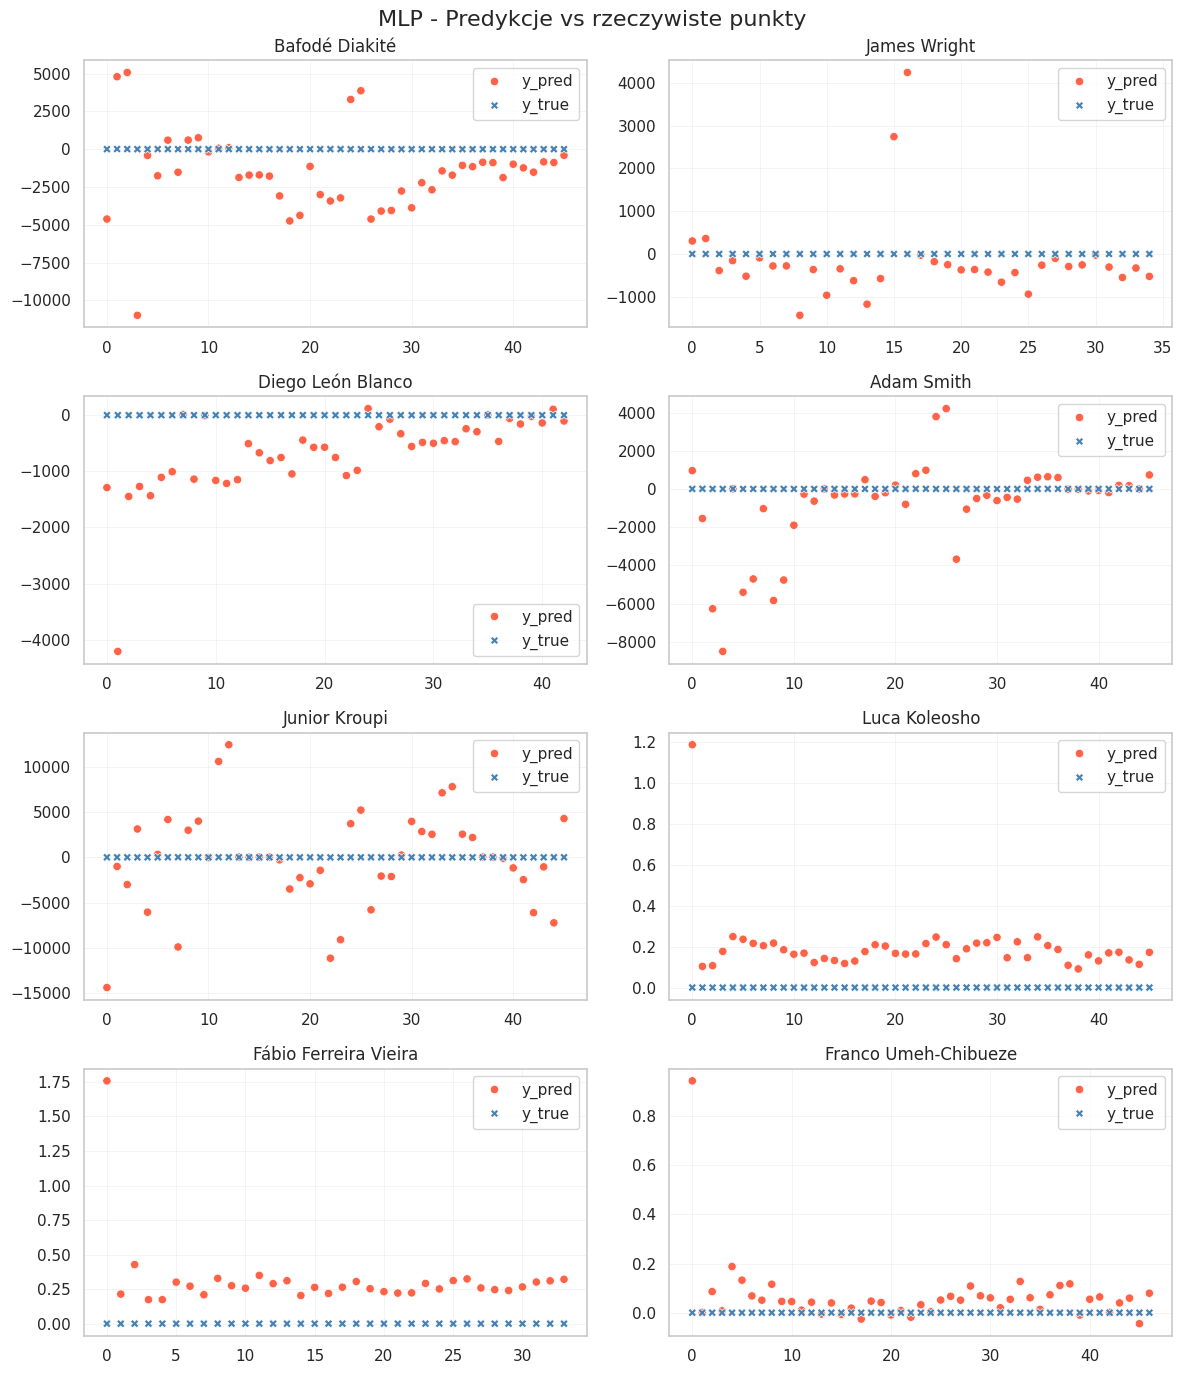

In [ ]:
fig, ax = plt.subplots(nrows=4, ncols=len(players) // 4, figsize=(12, 14))
for i, player in enumerate(players):
    sns.scatterplot(data=preds.loc[preds.name==player, ["y_pred", "y_true"]].reset_index(drop=True),
                    palette=["tomato", "steelblue"], ax=ax[i//2, i%2])
    ax[i//2, i%2].set_title(player)
plt.suptitle("MLP - Predykcje vs rzeczywiste punkty", fontsize=16)
plt.tight_layout();


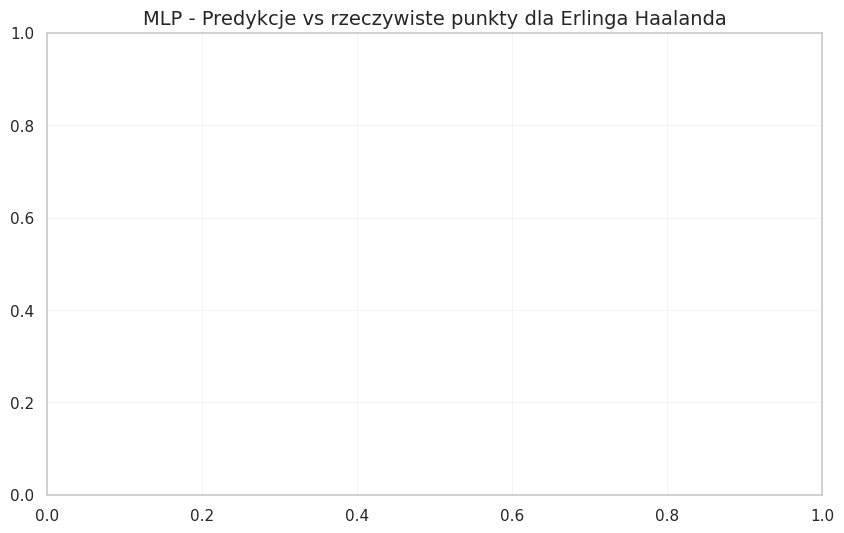

In [ ]:
plt.figure(figsize=(10, 6))
plt.title("MLP - Predykcje vs rzeczywiste punkty dla Erlinga Haalanda", fontsize=14)
sns.scatterplot(data=preds.loc[preds.name=="Erling Haaland", ["y_true", "y_pred"]].reset_index(drop=True));



In [ ]:
preds.to_parquet(config.PREDICTED_STATS_PATH)